# Notebook 02.1 — Limpeza, Correção Topológica e Análise Exploratória da Malha Viária

**Projeto:** Acessibilidade Geográfica às UBS de Teresina — roteiro computacional AE2SFCA  
**Programa:** MAPEPROF — Mestrado Profissional em Planejamento Urbano e Regional / IFPI  
**Autor:** Felipe Ramos Dantas  
**Orientador:** Prof. Dr. Antonio Joaquim da Silva  
**Coorientador:** Prof. Dr. Reurysson Chagas de Sousa Morais  
**Repositório:** https://github.com/felipedantas-pi/ae2sfca-ubs  
**Apêndice:** D · **Última atualização:** 2026-06-12

## Objetivo

Transformar os segmentos viários brutos extraídos da **Overture Maps** (NB 01.2) no
**grafo viário analítico** da pesquisa — a estrutura de dados central da dissertação,
sobre a qual serão calculados tempos de viagem (NB 03), isócronas (NB 04) e o índice
de acessibilidade AE2SFCA (NB 05).

A malha bruta **não chega pronta para análise de rede** por três motivos, e cada um
define uma etapa deste roteiro:

1. **Mistura de modos** — a Overture entrega rodovias e ferrovias juntas.
   → *Filtro semântico* (Seção 4).
2. **Topologia incompleta** — os cruzamentos não existem como nós do grafo; um segmento
   pode atravessar dezenas de esquinas sem "enxergá-las".
   → *Correção topológica* com `city2graph` (Seção 5).
3. **Atributos aninhados** — nome, superfície e velocidade vêm como estruturas JSON
   dentro das células, ilegíveis para análise tabular.
   → *Engenharia de atributos* (Seção 6).

Por ser a **primeira análise exploratória do grafo**, cada variável é caracterizada em
duas frentes: **estatística** (composição, completude, distribuições, cruzamentos) e
**cartográfica** (mapas temáticos com a moldura padrão da dissertação).

## Entrada

| Arquivo | Origem | Descrição |
|---|---|---|
| `dados/externos/overture/zonaUrbana_5km_segmentos.geojson` | NB 01.2 | Segmentos viários brutos (futuras arestas) |
| `dados/externos/overture/zonaUrbana_5km_conectores.geojson` | NB 01.2 | Conectores viários brutos (futuros nós) |
| `dados/externos/ibge/teresina_zonaUrbana_utm.parquet` | NB 01.1 | Limite da Zona Urbana (moldura cartográfica e densidade viária) |

## Saídas

Em `dados/intermediarios/02_grafo/`:

| Arquivo | Consumido por | Descrição |
|---|---|---|
| `zonaUrbana_5km_road_cleaned.parquet` | NB 02.2 (imputação GNN) | Grafo viário limpo, topologicamente íntegro e com atributos escalares |

Em `outputs/` (versionadas no repositório):

| Artefato | Descrição |
|---|---|
| `figuras/nb021/nb021_figNN_*.png` | Figuras da dissertação (nomes estáveis) |
| `tabelas/nb021_sintese_malha_viaria.csv` | Tabela-síntese dos indicadores da malha |

## Pré-requisitos

- **NB 01.1** e **NB 01.2** executados (arquivos de entrada presentes).
- Pacote `mapeprof` instalado no ambiente (`uv sync` na raiz do projeto).
- Sem necessidade de internet: todo o processamento é local.

---

## 1. Configuração e importações

Bibliotecas (geopandas, city2graph, networkx) e *helpers* do projeto (`src/mapeprof/`: config, viz, overture, geom); criação das subpastas de saída (`nb021`).

In [1]:
# ── 1. IMPORTAÇÕES E CONFIGURAÇÃO GLOBAL ────────────────────────────────────
import warnings

import city2graph as c2g
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Caminhos, CRS e helpers centralizados no pacote do projeto (src/mapeprof/).
# Regra do projeto: nenhum notebook redefine caminho, CRS ou função na mão —
# trocar de máquina (casa/escritório) exige ajustar apenas o symlink 'dados/'.
from mapeprof.config import (
    CRS_METRICO,  # EPSG:31983 — SIRGAS 2000 / UTM 23S (medições em metros)
    EXT_IBGE,  # dados/externos/ibge     — recortes territoriais do NB 01.1
    EXT_OVERTURE,  # dados/externos/overture — segmentos/conectores do NB 01.2
    FIGURAS,  # outputs/figuras — figuras da dissertação
    INT_GRAFO,  # dados/intermediarios/02_grafo — saída deste notebook
    TABELAS,  # outputs/tabelas — tabelas da dissertação
    criar_diretorios,
)
from mapeprof.geom import calcular_linearidade
from mapeprof.overture import (
    extrair_nome_via,
    extrair_superficie,
    extrair_velocidade_maxima,
)
from mapeprof.viz import (
    CORES_GROUP,
    CORES_SURF,
    ajustar_zoom_camada,
    aplicar_estilo,
    barra_escala,
    formatar_eixos_mapa,
    moldura_mapa,
    seta_norte,
)

aplicar_estilo()                    # estilo gráfico padronizado da dissertação
warnings.filterwarnings("ignore")   # silencia avisos de versão das bibliotecas
criar_diretorios()                  # garante a existência das pastas de saída

FIGURAS_NB = FIGURAS / "nb021"      # cada notebook grava figuras na própria subpasta
FIGURAS_NB.mkdir(parents=True, exist_ok=True)

TABELAS_NB = TABELAS / "nb021"
TABELAS_NB.mkdir(parents=True, exist_ok=True)


FONTE_PADRAO = "Overture Maps Foundation (2026); IBGE (2022). Elaboração própria."

print(f"✅ Setup concluído | city2graph {getattr(c2g, '__version__', 'dev')}")
print(f"   Entrada : {EXT_OVERTURE}")
print(f"   Saída   : {INT_GRAFO}")

✅ Setup concluído | city2graph 0.3.1
   Entrada : C:\Users\felipe\workspace_pcksa\ae2sfca_ubs\dados\externos\overture
   Saída   : C:\Users\felipe\workspace_pcksa\ae2sfca_ubs\dados\intermediarios\02_grafo


## 2. Carga dos dados brutos

O tema *transportation* da Overture Maps é distribuído em duas camadas complementares,
que correspondem exatamente aos dois componentes de um grafo:

- **`segment`** (linhas) — trechos de via, as futuras **arestas** da rede;
- **`connector`** (pontos) — junções potenciais entre trechos, os futuros **nós**.

Dois cuidados técnicos nesta carga:

1. **CRS métrico** — comprimentos e tolerâncias de *snap* são medidos em **metros**,
   o que exige a projeção SIRGAS 2000 / UTM 23S (EPSG:31983). O NB 01.2 já grava
   nesse CRS; o `to_crs` abaixo é uma salvaguarda barata caso os arquivos sejam
   regenerados em outro sistema.
2. **Atributos aninhados como texto** — o GeoJSON serializa as estruturas JSON da
   Overture (`names`, `road_surface`, `speed_limits`) como *strings*. As funções de
   extração do pacote `mapeprof` (Seção 6) parseiam esse texto de volta para as
   estruturas originais — nenhum tratamento extra é necessário aqui.

In [2]:
# ── 2. CARGA DOS DADOS BRUTOS (NB 01.2) ─────────────────────────────────────
print("🔄 Carregando malha viária bruta da área de estudo (Zona Urbana + 5 km)...")

segments_gdf   = gpd.read_file(EXT_OVERTURE / "zonaUrbana_5km_segmentos.geojson")
connectors_gdf = gpd.read_file(EXT_OVERTURE / "zonaUrbana_5km_conectores.geojson")

# Limite da Zona Urbana (NB 01.1) — moldura dos mapas e densidade viária (Seção 7)
zona_urbana_gdf = gpd.read_parquet(EXT_IBGE / "teresina_zonaUrbana_utm.parquet")
# Área de estudo (ZU + buffer 5 km) — moldura externa dos mapas
area_estudo_gdf = gpd.read_parquet(EXT_IBGE / "teresina_zonaUrbana_buffer5kClip_utm.parquet").to_crs(CRS_METRICO)


# Salvaguarda de CRS (ver nota metodológica acima)
segments_gdf    = segments_gdf.to_crs(CRS_METRICO)
connectors_gdf  = connectors_gdf.to_crs(CRS_METRICO)
zona_urbana_gdf = zona_urbana_gdf.to_crs(CRS_METRICO)

print(f"✅ Segmentos  : {len(segments_gdf):>7,} feições (arestas potenciais)")
print(f"✅ Conectores : {len(connectors_gdf):>7,} feições (nós potenciais)")
print(f"   CRS de trabalho: EPSG:{segments_gdf.crs.to_epsg()} (SIRGAS 2000 / UTM 23S)")

🔄 Carregando malha viária bruta da área de estudo (Zona Urbana + 5 km)...
✅ Segmentos  :  46,970 feições (arestas potenciais)
✅ Conectores :  35,183 feições (nós potenciais)
   CRS de trabalho: EPSG:31983 (SIRGAS 2000 / UTM 23S)


## 3. Análise exploratória da malha bruta

Antes de qualquer filtro ou transformação, caracterizamos o dado **como ele chegou da
fonte**. Essa fotografia inicial cumpre dois papéis na dissertação:

- **Transparência metodológica** — cada exclusão feita adiante é quantificada *antes*
  de acontecer, permitindo ao leitor auditar as decisões;
- **Diagnóstico de completude** — o percentual de preenchimento de cada variável revela,
  desde já, quais informações precisarão ser **imputadas** (classe funcional, NB 02.2)
  ou **modeladas teoricamente** (velocidades, NB 03).

In [3]:
# ── 3.1 INVENTÁRIO DE COMPLETUDE DAS VARIÁVEIS DE INTERESSE ─────────────────
# A baixa completude de algumas colunas é um RESULTADO da pesquisa, não um
# defeito do código: fundamenta as etapas de imputação e modelagem teórica.

VARIAVEIS_INTERESSE = {
    "subtype"      : "Tipo de infraestrutura (road, rail e outros)",
    "class"        : "Classe funcional da via (primary, residential e outros)",
    "names"        : "Nome(s) da via — estrutura aninhada",
    "road_surface" : "Tipo de superfície — estrutura aninhada",
    "speed_limits" : "Velocidade regulamentar — estrutura aninhada",
    "connectors"   : "Junções do segmento — liga arestas aos nós",
}

inventario = pd.DataFrame({
    "descricao"     : pd.Series(VARIAVEIS_INTERESSE),
    "preenchidas"   : [segments_gdf[c].notna().sum() for c in VARIAVEIS_INTERESSE],
    "preenchidas_%" : [
        round(segments_gdf[c].notna().mean() * 100, 1) for c in VARIAVEIS_INTERESSE
    ],
})

inventario.to_csv(TABELAS_NB / "nb021_inventario_completude.csv", sep=";", encoding="utf-8-sig")
inventario   # mantém a exibição

,descricao,preenchidas,preenchidas_%
subtype,"Tipo de infraestrutura (road, rail e outros)",46970,100.0
class,"Classe funcional da via (primary, residential ...",46970,100.0
names,Nome(s) da via — estrutura aninhada,36041,76.7
road_surface,Tipo de superfície — estrutura aninhada,13182,28.1
speed_limits,Velocidade regulamentar — estrutura aninhada,5593,11.9
connectors,Junções do segmento — liga arestas aos nós,46970,100.0


In [4]:
# ── 3.2 COMPOSIÇÃO POR SUBTIPO DE INFRAESTRUTURA ────────────────────────────
# A Overture mistura modos de transporte. Para o AE2SFCA interessa apenas o
# subtipo 'road': pacientes deslocam-se às UBS pela rede rodoviária (a pé ou
# de carro). A tabela quantifica o que será removido na Seção 4.

extensao_km_subtipo = (
    segments_gdf.geometry.length.groupby(segments_gdf["subtype"]).sum() / 1_000
)

tabela_subtipos = pd.DataFrame({
    "segmentos"    : segments_gdf["subtype"].value_counts(dropna=False),
    "percentual_%" : (
        segments_gdf["subtype"].value_counts(normalize=True, dropna=False) * 100
    ).round(2),
    "extensao_km"  : extensao_km_subtipo.round(1),
})
print("--- Composição da malha bruta por subtipo ---")
tabela_subtipos.to_csv(TABELAS_NB / "nb021_composicao_subtipos.csv", sep=";", encoding="utf-8-sig")
tabela_subtipos   # mantém a exibição

--- Composição da malha bruta por subtipo ---


,segmentos,percentual_%,extensao_km
subtype,,,
rail,38,0.08,42.2
road,46932,99.92,4817.7


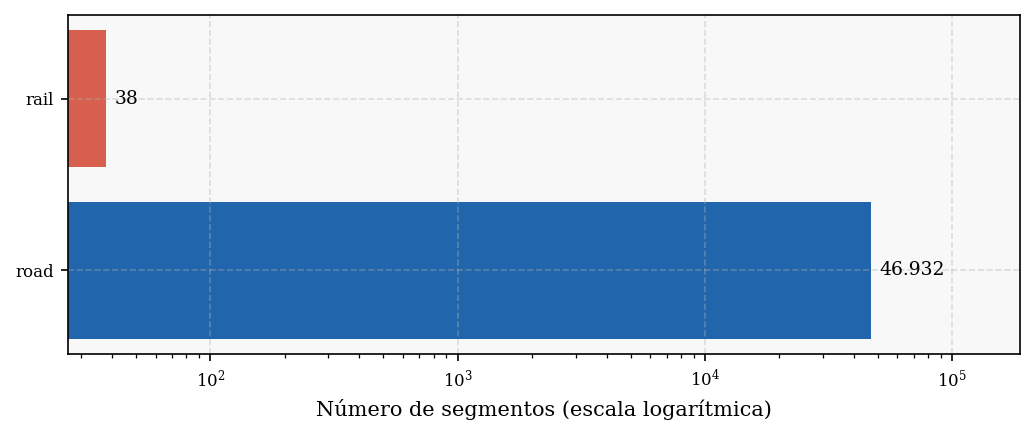

In [5]:
# ── Fig. 01 — Composição da malha bruta por subtipo ─────────────────────────
contagem_subtipo = segments_gdf["subtype"].value_counts()

# 1. Dicionário de tradução das categorias da Overture Maps para PT-BR
traducao_subtipos = {
    "road": "Rodovia / Rua",
    "rail": "Ferrovia",
    "path": "Caminho / Trilha",
    "water": "Hidrovia",
    "unknown": "Desconhecido"
}

# 2. Aplica a tradução. Se o termo original não estiver no dicionário, 
# a função .get() utiliza o próprio termo original com a primeira letra maiúscula (.title())
rotulos_traduzidos = [traducao_subtipos.get(str(idx).lower(), str(idx).title()) for idx in contagem_subtipo.index]

fig, ax = plt.subplots(figsize=(7, 3))
barras = ax.barh(
    contagem_subtipo.index.astype(str), contagem_subtipo.values,
    color=["#2166AC", "#D6604D"],
)

# Rótulos absolutos: com dezenas de milhares de 'road' contra dezenas de
# 'rail', a leitura direta dos números é mais honesta que a comparação visual.
for barra, valor in zip(barras, contagem_subtipo.values):
    # Formatação PT-BR: converte a vírgula do milhar americano em ponto
    texto_valor = f"{valor:,}".replace(",", ".")
    ax.text(valor * 1.08, barra.get_y() + barra.get_height() / 2,
            texto_valor, va="center", fontsize=9)

ax.set_xscale("log")   # escala logarítmica: torna a barra de 'rail' visível
ax.set_xlim(right=contagem_subtipo.max() * 4)
ax.set_xlabel("Número de segmentos (escala logarítmica)")
plt.tight_layout()
plt.savefig(FIGURAS_NB / "nb021_fig01_composicao_subtipos.png", bbox_inches="tight")
plt.show()

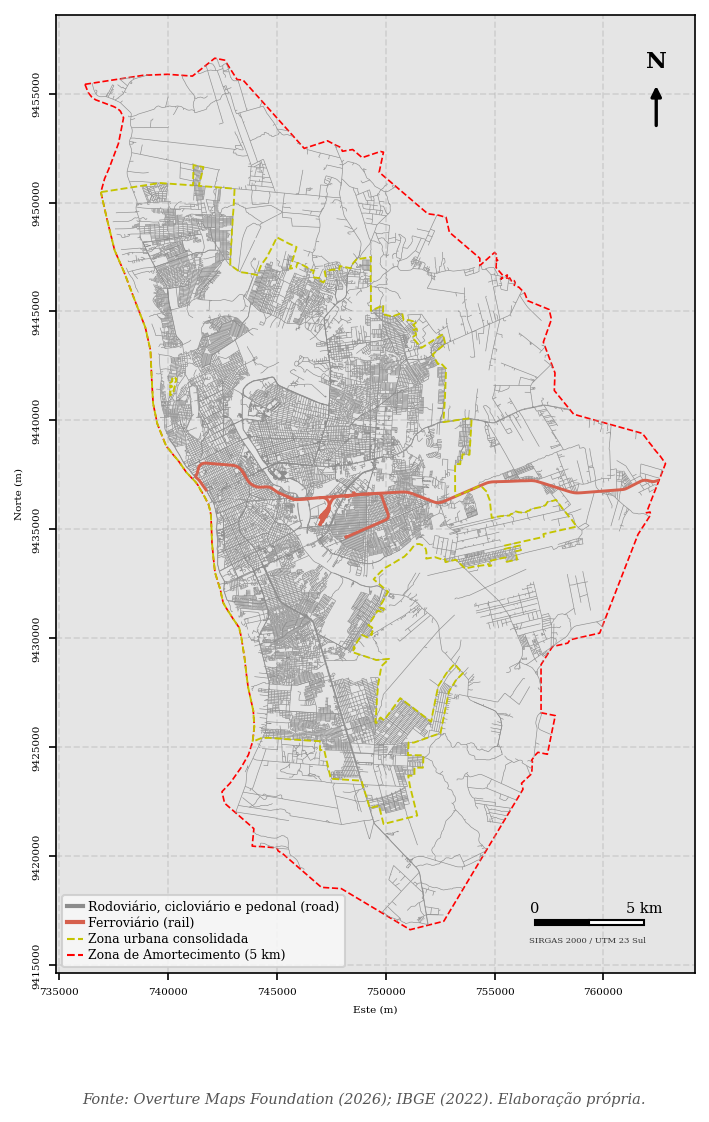

In [6]:
# ── Fig. 02 — Mapa da malha bruta: rodovias vs. ferrovias ───────────────────
fig, ax = plt.subplots(figsize=(5.8, 8.3)); ax.set_facecolor("#E5E5E5")

area_estudo_gdf.boundary.plot(ax=ax, color="#FF0000", ls="--", lw=0.8, zorder=1)   # área de estudo
segments_gdf[segments_gdf["subtype"] == "road"].plot(ax=ax, color="#8C8C8C", linewidth=0.3, zorder=2)
segments_gdf[segments_gdf["subtype"] == "rail"].plot(ax=ax, color="#D6604D", linewidth=1.4, zorder=3)
zona_urbana_gdf.boundary.plot(ax=ax, color="#C4C400", ls="--", lw=0.9, zorder=4)   # zona urbana

ax.legend(handles=[
    Line2D([], [], color="#8C8C8C", lw=2, label="Rodoviário, cicloviário e pedonal (road)"),
    Line2D([], [], color="#D6604D", lw=2, label="Ferroviário (rail)"),
    Line2D([], [], color="#C4C400", ls="--", lw=1, label="Zona urbana consolidada"),
    Line2D([], [], color="#FF0000", ls="--", lw=1, label="Zona de Amortecimento (5 km)"),
], loc="lower left", fontsize=6)

ajustar_zoom_camada(ax, area_estudo_gdf, margem=0.05)
moldura_mapa(ax, "", FONTE_PADRAO)
formatar_eixos_mapa(ax, fontsize=5)

# barra_escala subida (frac_y maior) pra abrir espaço pro texto do CRS abaixo dela
barra_escala(ax, frac_x=0.75, frac_y=0.05)
seta_norte(ax)

x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
ax.text(x0 + (x1 - x0) * 0.74, y0 + (y1 - y0) * 0.03,
        "SIRGAS 2000 / UTM 23 Sul", ha="left", va="bottom",
        fontsize=4, color="#333333", zorder=10)

plt.savefig(FIGURAS_NB / "nb021_fig02_mapa_malha_bruta.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Filtro semântico: apenas infraestrutura rodoviária

Ferrovias são removidas porque **não participam do deslocamento paciente → UBS**:
não são roteáveis a pé nem de carro e, se permanecessem, criariam falsas conexões
no grafo (um cruzamento rodoferroviário viraria uma "esquina" pela qual o algoritmo
de rota tentaria passar).

In [7]:
# ── 4. FILTRO SEMÂNTICO ─────────────────────────────────────────────────────
total_bruto = len(segments_gdf)
road_gdf = segments_gdf[segments_gdf["subtype"] == "road"].copy()
removidos = total_bruto - len(road_gdf)

print(f"🧹 Removidos {removidos:,} segmentos não-rodoviários "
      f"({removidos / total_bruto * 100:.2f}% da malha bruta).")
print(f"   Malha rodoviária resultante: {len(road_gdf):,} segmentos.")

🧹 Removidos 38 segmentos não-rodoviários (0.08% da malha bruta).
   Malha rodoviária resultante: 46,932 segmentos.


## 5. Correção topológica (`city2graph`)

Esta é a etapa **mais crítica** para a validade das isócronas (NB 04). Na malha bruta,
um segmento pode atravessar dezenas de cruzamentos sem que eles existam como nós — o
algoritmo de roteamento "passaria direto" pelas esquinas, superestimando distâncias e
tempos de viagem.

A função `c2g.process_overture_segments()` executa duas operações:

1. **Connector splitting** — cada segmento é **fatiado** nos pontos onde a camada
   `connector` indica uma junção. O resultado são arestas curtas cujas extremidades
   coincidem com os nós reais da rede. Por isso o número de feições **aumenta** após
   o processamento: nenhuma via foi criada, apenas particionada.
2. **Endpoint clustering** — extremidades a menos de `threshold` metros umas das
   outras são fundidas (*snap*), eliminando micro-lacunas de digitalização que
   desconectariam ruas adjacentes.

**Escolha do `threshold = 3.0 m`** — menor que a largura de uma pista de rolamento
(não funde vias paralelas distintas) e maior que os desvios típicos de digitalização
da fonte (corrige as lacunas reais).

> ⚠️ A coluna `level_rules` precisa estar presente nesta chamada (a função a utiliza
> para tratar viadutos/túneis), por isso a seleção final de colunas ocorre apenas na
> exportação (Seção 8).

In [8]:
# ── 5. CORREÇÃO TOPOLÓGICA ──────────────────────────────────────────────────
print("⚙️ Processando topologia (splitting + snapping)... ⏳ ~1 minuto")

arestas_gdf = c2g.process_overture_segments(
    segments_gdf=road_gdf,
    connectors_gdf=connectors_gdf,
    get_barriers=False,   # barreiras só são usadas pelo morphological_graph()
    threshold=3.0,        # tolerância de snap, em METROS (exige CRS métrico)
)

print(f"✅ Topologia corrigida: {len(road_gdf):,} segmentos → "
      f"{len(arestas_gdf):,} arestas.")
print("   O aumento é esperado: segmentos longos foram fatiados a cada interseção.")

⚙️ Processando topologia (splitting + snapping)... ⏳ ~1 minuto
✅ Topologia corrigida: 46,932 segmentos → 52,977 arestas.
   O aumento é esperado: segmentos longos foram fatiados a cada interseção.


In [9]:
# ── 5.1 VALIDAÇÃO DE INTEGRIDADE PÓS-PROCESSAMENTO ──────────────────────────
# Três checagens garantem que a correção não corrompeu o dado:
#   (1) o CRS métrico foi preservado;
#   (2) a extensão total da rede se manteve — fatiar não cria nem destrói via;
#   (3) cada aresta possui uma chave única — exigência da montagem do grafo
#       no NB 02.2. O id da Overture NÃO cumpre esse papel após o fatiamento
#       (trechos derivados herdam o id, e a fonte traz raras feições com id
#       repetido), por isso criamos a chave primária do pipeline: 'aresta_id'.

extensao_antes_km  = road_gdf.geometry.length.sum() / 1_000
extensao_depois_km = arestas_gdf.geometry.length.sum() / 1_000
variacao_pct = abs(1 - extensao_depois_km / extensao_antes_km) * 100

arestas_fatiadas       = int(arestas_gdf["split_from"].notna().sum())
ids_overture_repetidos = int(arestas_gdf["id"].duplicated().sum())

# Chave primária única e estável (aresta_000000, aresta_000001, ...)
arestas_gdf = arestas_gdf.reset_index(drop=True)
arestas_gdf["aresta_id"] = "aresta_" + arestas_gdf.index.astype(str).str.zfill(6)

print(f"(1) CRS preservado (EPSG:31983) : {arestas_gdf.crs.to_epsg() == 31983}")
print(f"(2) Extensão antes → depois     : {extensao_antes_km:,.1f} km → "
      f"{extensao_depois_km:,.1f} km (variação de {variacao_pct:.3f}%)")
print(f"(3) Arestas fatiadas: {arestas_fatiadas:,} | ids Overture repetidos: "
      f"{ids_overture_repetidos} → chave primária 'aresta_id' criada "
      f"(única: {arestas_gdf['aresta_id'].is_unique})")

(1) CRS preservado (EPSG:31983) : True
(2) Extensão antes → depois     : 4,817.7 km → 4,817.7 km (variação de 0.001%)
(3) Arestas fatiadas: 9,714 | ids Overture repetidos: 16 → chave primária 'aresta_id' criada (única: True)


### 5.2 Conectividade e morfologia do grafo

Um grafo viário só serve ao cálculo de isócronas se for **conexo**: ilhas isoladas
são inalcançáveis pelo roteamento e distorceriam o indicador de acessibilidade.
Verificamos aqui:

- **Componentes conexos** — quantas "ilhas" a rede possui e que fração dos nós está
  no *componente gigante*. Ilhas pequenas costumam ser condomínios fechados e vias
  privadas; a decisão de removê-las é adiada para o NB 03 (filtro de roteabilidade).
- **Valência das interseções (grau dos nós)** — grau 1 = ponta solta (*cul-de-sac*),
  grau 3 = interseção em "T", grau 4 = cruzamento completo. A proporção entre elas é
  uma assinatura morfológica da cidade: malhas ortogonais planejadas são ricas em
  grau 4; tecidos de expansão não planejada são ricos em grau 1 e 3.

In [10]:
# ── 5.2 CONECTIVIDADE E VALÊNCIA DAS INTERSEÇÕES ────────────────────────────
# Grafo auxiliar: nós = extremidades das arestas (após o snapping, pontas
# coincidentes são o MESMO ponto — é essa coincidência que conecta a rede).
G = nx.Graph()
for geom in arestas_gdf.geometry:
    G.add_edge(geom.coords[0], geom.coords[-1])

componentes = sorted(nx.connected_components(G), key=len, reverse=True)
n_componentes = len(componentes)
pct_gigante = len(componentes[0]) / G.number_of_nodes() * 100

print(f"🕸️ Nós: {G.number_of_nodes():,} | Componentes conexos: {n_componentes}")
print(f"   Componente gigante: {len(componentes[0]):,} nós ({pct_gigante:.2f}%) "
      f"→ rede apta ao roteamento.")
print(f"   Demais componentes (ilhas): {[len(c) for c in componentes[1:6]]}... nós")

graus = pd.Series([grau for _, grau in G.degree()], name="grau")
tabela_graus = pd.DataFrame({
    "intersecoes"  : graus.value_counts().sort_index(),
    "percentual_%" : (graus.value_counts(normalize=True).sort_index() * 100).round(1),
})
pct_pontas_soltas = (graus == 1).mean() * 100

print("\n--- Valência das interseções (grau do nó) ---")
print(tabela_graus.head(8).to_string())
print(f"\nPontas soltas/cul-de-sac (grau 1): {pct_pontas_soltas:.1f}% — "
      "predomínio de 'T' (grau 3) sobre cruzamentos completos (grau 4).")

# Salva a valência das interseções (grau dos nós) em tabela
tabela_graus.index.name = "grau"
tabela_graus.to_csv(TABELAS_NB / "nb021_valencia_intersecoes.csv", sep=";", encoding="utf-8-sig")

🕸️ Nós: 35,187 | Componentes conexos: 45
   Componente gigante: 34,966 nós (99.37%) → rede apta ao roteamento.
   Demais componentes (ilhas): [55, 26, 18, 16, 10]... nós

--- Valência das interseções (grau do nó) ---
      intersecoes  percentual_%
grau                           
1            4012          11.4
2            1655           4.7
3           20221          57.5
4            9192          26.1
5              60           0.2
6              38           0.1
7               7           0.0
8               2           0.0

Pontas soltas/cul-de-sac (grau 1): 11.4% — predomínio de 'T' (grau 3) sobre cruzamentos completos (grau 4).


## 6. Engenharia de atributos

A Overture armazena vários atributos como **estruturas JSON aninhadas** dentro das
células (ex.: `[{'value': 'paved', 'between': None}]`), ilegíveis para análise tabular
e para a GNN. As funções de extração vivem em `src/mapeprof/overture.py` e
`src/mapeprof/geom.py` — testáveis, documentadas e reutilizáveis por qualquer notebook;
aqui elas são apenas **aplicadas**.

| Variável | Fonte (coluna bruta) | Tipo | Papel no pipeline |
|---|---|---|---|
| `nomes_vias` | `names` | texto | Auditoria visual e relatórios |
| `surface_clean` / `surf_group` | `road_surface` | categórica | *Feature* da GNN (NB 02.2); impedância diferenciada (NB 03) |
| `velocidade_max` | `speed_limits` | numérica (km/h) | Referência empírica para a matriz de velocidades (NB 03) |
| `length_m` | geometria | numérica (m) | *Feature* da GNN; numerador da impedância (NB 03) |
| `linearity` | geometria | numérica [0–1] | *Feature* da GNN (morfologia da via) |
| `classe_original` | `class` | categórica | Cópia de auditoria — a GNN sobrescreverá `class` |

### 6.1 Nome das vias

O nome vem na estrutura `{'primary': 'Av. Frei Serafim', ...}`. Além do percentual de
preenchimento, fazemos uma **validação por reconhecimento**: as vias de maior extensão
devem ser corredores conhecidos de Teresina. Se aparecerem nomes estranhos no topo,
algo está errado na extração — um *sanity check* qualitativo simples e eficaz.

In [11]:
# ── 6.1 NOME DAS VIAS ───────────────────────────────────────────────────────
arestas_gdf["nomes_vias"] = arestas_gdf["names"].apply(extrair_nome_via)

n_com_nome = arestas_gdf["nomes_vias"].notna().sum()
print(f"✅ Arestas com nome: {n_com_nome:,} "
      f"({n_com_nome / len(arestas_gdf) * 100:.1f}%)")

top10_vias = (
    arestas_gdf.dropna(subset=["nomes_vias"])
    .assign(km=lambda d: d.geometry.length / 1_000)
    .groupby("nomes_vias")["km"].sum()
    .sort_values(ascending=False)
    .head(10)
    .round(1)
)
print("\n--- 10 vias de maior extensão na área de estudo (km) ---")
print(top10_vias.to_string())

✅ Arestas com nome: 39,012 (73.6%)

--- 10 vias de maior extensão na área de estudo (km) ---
nomes_vias
Avenida Prefeito Wall Ferraz    33.3
Rua Um                          25.8
Rua Três                        25.7
Avenida João XXIII              21.4
Avenida Presidente Kennedy      19.5
Rua Dois                        19.3
Avenida Maranhão                16.6
Avenida Miguel Rosa             15.6
Rua Cinco                       14.8
Rua Sete                        14.3


### 6.2 Superfície da via

Estrutura bruta: `[{'value': 'paved', 'between': None}]`. A superfície é central para
a **hipótese de desigualdade territorial (H2)**: vias não pavimentadas penalizam o
tempo de viagem (NB 03) e tendem a se concentrar na periferia — exatamente onde a
acessibilidade às UBS é mais sensível.

O alto percentual de `unknown` é esperado (a Overture só registra superfície onde há
mapeamento de origem) e **não invalida a variável**: ela será usada como *feature*
na GNN, e o grupo desconhecido é tratado explicitamente.

In [12]:
# ── 6.2 SUPERFÍCIE DA VIA ───────────────────────────────────────────────────
arestas_gdf["surface_clean"] = arestas_gdf["road_surface"].apply(extrair_superficie)

# Agrupamento em 3 classes — legível em mapa e alinhado ao uso no NB 03
MAPA_GRUPOS_SUPERFICIE = {
    "paved": "Pavimentada", "paving_stones": "Pavimentada",
    "unpaved": "Não pavimentada", "gravel": "Não pavimentada",
    "dirt": "Não pavimentada",
    "unknown": "Desconhecida",
}
arestas_gdf["surf_group"] = (
    arestas_gdf["surface_clean"].map(MAPA_GRUPOS_SUPERFICIE).fillna("Desconhecida")
)

km_por_superficie = (
    arestas_gdf.geometry.length.groupby(arestas_gdf["surface_clean"]).sum() / 1_000
)
tabela_superficie = pd.DataFrame({
    "arestas"      : arestas_gdf["surface_clean"].value_counts(),
    "percentual_%" : (
        arestas_gdf["surface_clean"].value_counts(normalize=True) * 100
    ).round(1),
    "extensao_km"  : km_por_superficie.round(1),
}).sort_values("arestas", ascending=False)

print("--- Distribuição do atributo de superfície ---")
tabela_superficie.to_csv(TABELAS_NB / "nb021_superficie_via.csv", sep=";", encoding="utf-8-sig")
tabela_superficie

--- Distribuição do atributo de superfície ---


,arestas,percentual_%,extensao_km
surface_clean,,,
unknown,37562,70.9,3463.1
paved,12724,24.0,1030.8
unpaved,1306,2.5,194.4
paving_stones,812,1.5,68.0
dirt,567,1.1,61.1
gravel,6,0.0,0.3


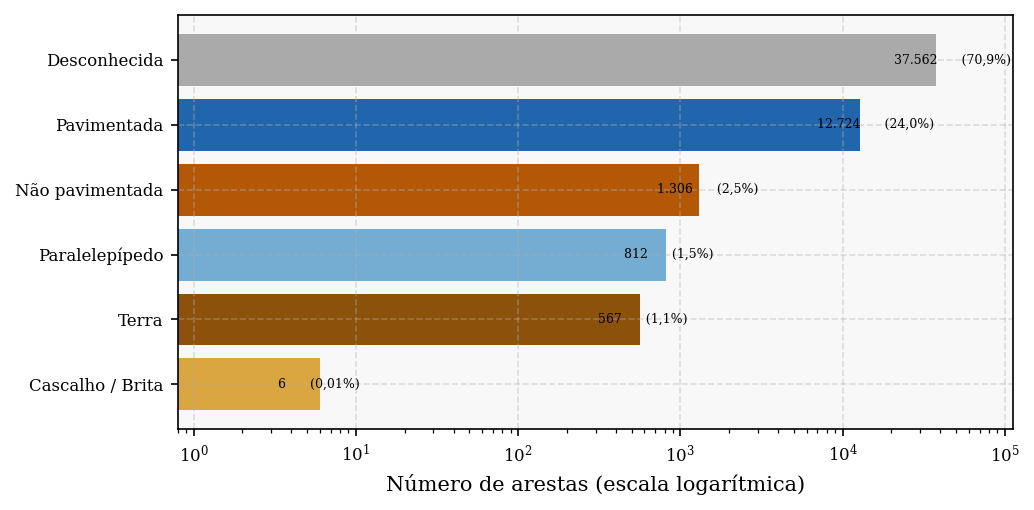

In [13]:
# ── Fig. 03 — Composição do atributo de superfície ──────────────────────────
ordem_barras = tabela_superficie.index[::-1]   # maior categoria no topo do eixo
cores_barras = [CORES_SURF.get(s, "#999999") for s in ordem_barras]

# 1. Dicionário de tradução das superfícies da Overture Maps para PT-BR
traducao_superficie = {
    "paved": "Pavimentada",
    "unpaved": "Não pavimentada",
    "gravel": "Cascalho / Brita",
    "dirt": "Terra",
    "paving_stones": "Paralelepípedo",
    "unknown": "Desconhecida"
}

# 2. Aplica a tradução aos rótulos do eixo Y
rotulos_traduzidos = [traducao_superficie.get(str(idx).lower(), str(idx).title()) for idx in ordem_barras]

fig, ax = plt.subplots(figsize=(7, 3.5))

# 3. Plota as barras usando os rótulos traduzidos
ax.barh(rotulos_traduzidos, tabela_superficie.loc[ordem_barras, "arestas"],
        color=cores_barras)

total = tabela_superficie["arestas"].sum()
for i, superficie in enumerate(ordem_barras):
    n   = tabela_superficie.loc[superficie, "arestas"]
    pct = n / total * 100                              # recalcula sem o arredondamento da tabela

    texto_n  = f"{n:,}".replace(",", ".")              # milhar PT-BR
    casas    = 2 if pct < 0.1 else 1                   # mais casas para categorias minúsculas
    texto_pct = f"{pct:.{casas}f}".replace(".", ",")   # vírgula decimal PT-BR

    ax.text(n * 0.55, i, f"{texto_n}      ({texto_pct}%)", va="center", fontsize=6)


ax.set_xscale("log")
ax.set_xlim(0.8, tabela_superficie["arestas"].max() * 3)
ax.set_xlabel("Número de arestas (escala logarítmica)")
plt.tight_layout()
plt.savefig(FIGURAS_NB / "nb021_fig03_composicao_superficie_log.png", bbox_inches="tight")
plt.show()

In [ ]:
# ── 6.2.1 CRUZAMENTO: SUPERFÍCIE × CLASSE FUNCIONAL ─────────────────────────
# Pergunta de pesquisa embutida: as vias sem pavimentação se distribuem
# igualmente pela hierarquia viária, ou se concentram em classes específicas?
# A resposta fundamenta DUAS decisões: usar superfície como feature da GNN
# (NB 02.2) e penalizar vias de terra na impedância (NB 03).

classes_principais = arestas_gdf["class"].value_counts().head(8).index
mascara = arestas_gdf["class"].isin(classes_principais)

cruzamento_superficie_classe = (
    pd.crosstab(
        arestas_gdf.loc[mascara, "class"],
        arestas_gdf.loc[mascara, "surf_group"],
        normalize="index",          # percentual DENTRO de cada classe
    ) * 100
).round(1)

cruzamento_superficie_classe.to_csv(TABELAS_NB / "nb021_superficie_x_classe.csv", sep=";", encoding="utf-8-sig")

print("--- Superfície por classe funcional (% na linha) ---")
print(cruzamento_superficie_classe.to_string())
print("\n💡 Leitura: a concentração de 'Não pavimentada' nas classes residencial e")
print("   unclassified indica que as lacunas de classificação são, em grande parte,")
print("   vias periféricas de terra — evidência que conecta a imputação GNN à H1.")

--- Superfície por classe funcional (% na linha) ---
surf_group     Desconhecida  Não pavimentada  Pavimentada
class                                                    
footway                68.1              0.2         31.7
living_street          94.9              0.2          5.0
primary                26.0              0.0         74.0
residential            80.0              4.2         15.9
secondary              10.9              0.0         89.1
service                87.9              0.8         11.3
tertiary               53.2              0.0         46.7
unclassified           59.5             31.1          9.3

💡 Leitura: a concentração de 'Não pavimentada' nas classes residencial e
   unclassified indica que as lacunas de classificação são, em grande parte,
   vias periféricas de terra — evidência que conecta a imputação GNN à H2.


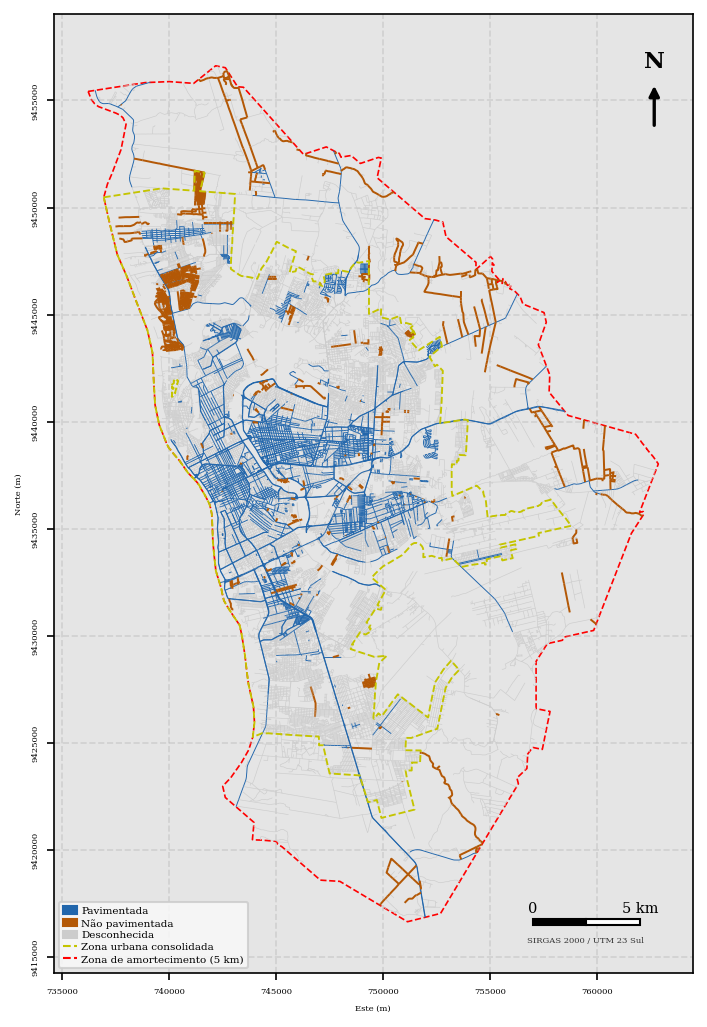

In [ ]:
# ── Fig. 04 — Mapa da superfície viária (3 grupos) ──────────────────────────
fig, ax = plt.subplots(figsize=(5.8, 8.3)); ax.set_facecolor("#E5E5E5")

area_estudo_gdf.boundary.plot(ax=ax, color="#FF0000", ls="--", lw=0.8, zorder=1)
# Desconhecida ao fundo; Não pavimentada por cima e mais espessa (interesse da H1)
for grupo, largura in (("Desconhecida", 0.3), ("Pavimentada", 0.45), ("Não pavimentada", 0.95)):
    arestas_gdf[arestas_gdf["surf_group"] == grupo].plot(ax=ax, color=CORES_GROUP[grupo], linewidth=largura, zorder=2)
zona_urbana_gdf.boundary.plot(ax=ax, color="#C4C400", ls="--", lw=0.9, zorder=4)

ax.legend(
    handles=[Patch(color=CORES_GROUP[g], label=g) for g in ("Pavimentada", "Não pavimentada", "Desconhecida")]
            + [Line2D([], [], color="#C4C400", ls="--", lw=1, label="Zona urbana consolidada"),
               Line2D([], [], color="#FF0000", ls="--", lw=1, label="Zona de amortecimento (5 km)")],
    loc="lower left", fontsize=5)

ajustar_zoom_camada(ax, area_estudo_gdf, margem=0.06)
formatar_eixos_mapa(ax, fontsize=4)

# barra_escala subida (frac_y maior) pra abrir espaço pro texto do CRS abaixo dela
barra_escala(ax, frac_x=0.75, frac_y=0.05)
seta_norte(ax)

x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
ax.text(x0 + (x1 - x0) * 0.74, y0 + (y1 - y0) * 0.03,
        "SIRGAS 2000 / UTM 23 Sul", ha="left", va="bottom",
        fontsize=4, color="#333333", zorder=10)

plt.savefig(FIGURAS_NB / "nb021_fig04_mapa_superficie.png", dpi=300, bbox_inches="tight")
plt.show()

### 6.3 Velocidade regulamentar

Estrutura bruta: `[{'max_speed': {'value': 60.0, 'unit': 'km/h'}, ...}]`. O registro é
**esparso** — só existe onde há sinalização mapeada —, por isso a variável não pode
alimentar diretamente o cálculo de impedâncias. Seu papel é outro: fornecer a
**referência empírica local** para calibrar a matriz de velocidades teóricas por
classe funcional (`SPEED_DICT`, NB 03), em vez de depender apenas da literatura.

In [16]:
# ── 6.3 VELOCIDADE REGULAMENTAR ─────────────────────────────────────────────
arestas_gdf["velocidade_max"] = (
    arestas_gdf["speed_limits"].apply(extrair_velocidade_maxima)
)

n_com_velocidade = arestas_gdf["velocidade_max"].notna().sum()
print(f"✅ Arestas com velocidade regulamentar: {n_com_velocidade:,} "
      f"({n_com_velocidade / len(arestas_gdf) * 100:.1f}%)")
print("\n--- Estatísticas descritivas (km/h) ---")
print(arestas_gdf["velocidade_max"].describe().round(1).to_string())

# Mediana observada por classe funcional: insumo de calibração do NB 03
tabela_velocidade_classe = (
    arestas_gdf.groupby("class")["velocidade_max"]
    .agg(arestas_com_dado="count", mediana_kmh="median")
    .query("arestas_com_dado > 0")
    .sort_values("mediana_kmh", ascending=False)
)
print("\n--- Velocidade mediana observada por classe funcional ---")
print(tabela_velocidade_classe.to_string())

# Salva as estatísticas de velocidade
desc_vel = arestas_gdf["velocidade_max"].describe().round(1)
desc_vel.index.name = "estatistica"          # rotula o índice (count, mean, ...)
desc_vel.name = "velocidade_kmh"             # rotula a coluna de valores
desc_vel.to_csv(TABELAS_NB / "nb021_velocidade_descritiva.csv", sep=";", encoding="utf-8-sig")

tabela_velocidade_classe.to_csv(
    TABELAS_NB / "nb021_velocidade_por_classe.csv", sep=";", encoding="utf-8-sig"
)

✅ Arestas com velocidade regulamentar: 6,920 (13.1%)

--- Estatísticas descritivas (km/h) ---
count    6920.0
mean       54.4
std        12.0
min        10.0
25%        50.0
50%        60.0
75%        60.0
max       100.0

--- Velocidade mediana observada por classe funcional ---
               arestas_com_dado  mediana_kmh
class                                       
trunk                       375         80.0
unknown                       4         80.0
tertiary                   1231         60.0
secondary                  1876         60.0
primary                    1994         60.0
residential                1274         40.0
unclassified                 26         40.0
path                          3         30.0
living_street                18         25.0
service                     119         20.0


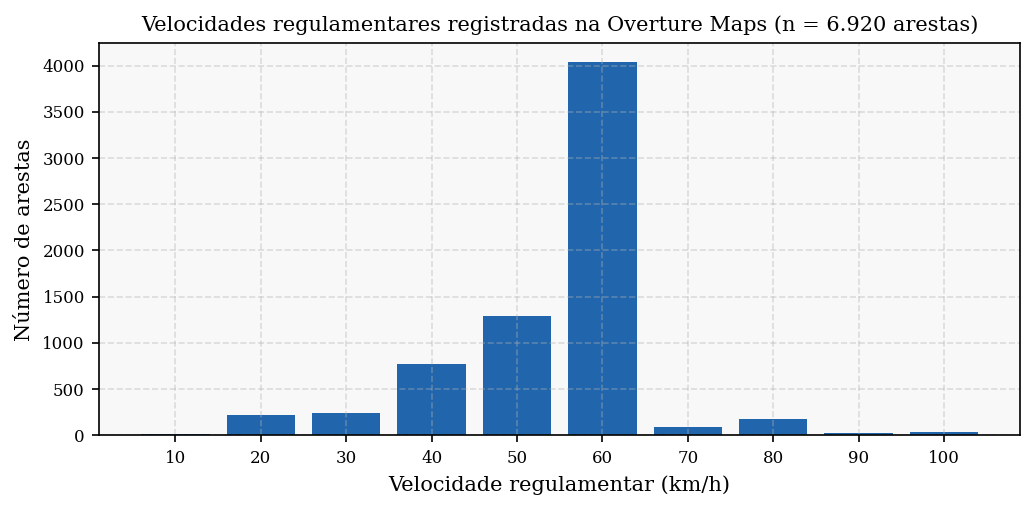

In [17]:
# ── Fig. 05 — Distribuição das velocidades regulamentares ───────────────────
contagem_velocidade = arestas_gdf["velocidade_max"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(contagem_velocidade.index.astype(int).astype(str),
       contagem_velocidade.values, color="#2166AC")
ax.set_xlabel("Velocidade regulamentar (km/h)")
ax.set_ylabel("Número de arestas")
ax.set_title("Velocidades regulamentares registradas na Overture Maps "
             f"(n = {int(contagem_velocidade.sum()):,} arestas)".replace(",", "."))

plt.tight_layout()
plt.savefig(FIGURAS_NB / "nb021_fig05_velocidades.png", bbox_inches="tight")
plt.show()

### 6.4 Comprimento e linearidade

Duas *features* puramente geométricas, calculadas para alimentar a GNN (NB 02.2):

- **`length_m`** — comprimento da aresta em metros, recalculado da geometria para
  garantir a unidade do CRS métrico.
- **`linearity`** — razão entre a distância euclidiana ponta-a-ponta e o comprimento
  real do traçado (função `calcular_linearidade`, em `src/mapeprof/geom.py`):

$$\text{linearity} = \frac{\operatorname{dist}(P_{inicial},\; P_{final})}{\text{comprimento da via}} \in [0, 1]$$

A linearidade captura a **tortuosidade**: valores próximos de 1 indicam vias retilíneas
(típico de avenidas planejadas); valores baixos indicam traçados sinuosos (becos, vias
de ocupação irregular). A premissa morfológica é que a forma da via carrega informação
sobre sua **hierarquia funcional** — é isso que a GNN explorará.

In [18]:
# ── 6.4 COMPRIMENTO E LINEARIDADE ───────────────────────────────────────────
arestas_gdf["length_m"]  = arestas_gdf.geometry.length
arestas_gdf["linearity"] = arestas_gdf.geometry.apply(calcular_linearidade)

print("--- Estatísticas descritivas das features geométricas ---")
arestas_gdf[["length_m", "linearity"]].describe().round(3)

--- Estatísticas descritivas das features geométricas ---


,length_m,linearity
count,52977.000,52977.000
mean,90.940,0.985
std,115.350,0.078
min,0.000,0.000
25%,40.739,1.000
50%,66.962,1.000
75%,110.513,1.000
max,4780.985,1.000


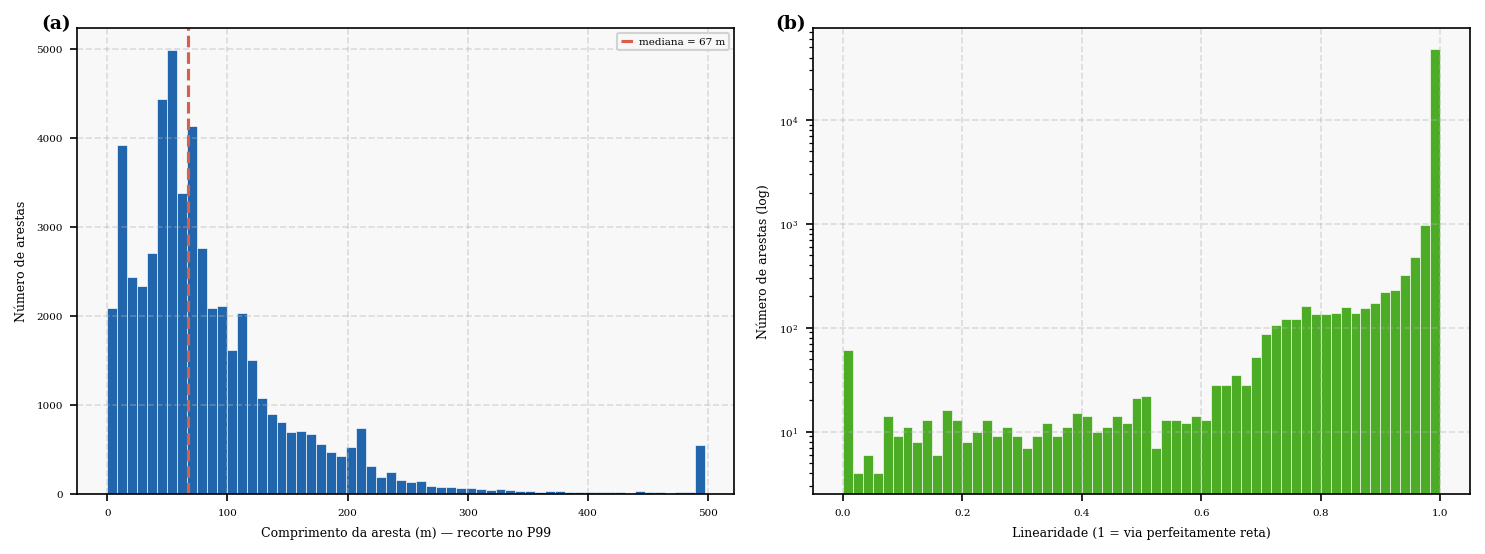

In [ ]:
# ── Fig. 06 — Distribuições de comprimento e linearidade ────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8))

# Comprimento: recorte no percentil 99 para a cauda longa (poucas rodovias
# muito extensas) não esmagar a visualização do corpo da distribuição.
p99 = arestas_gdf["length_m"].quantile(0.99)
mediana_m = arestas_gdf["length_m"].median()
ax1.hist(arestas_gdf["length_m"].clip(upper=p99), bins=60,
         color="#2166AC", edgecolor="white", linewidth=0.3)
ax1.axvline(mediana_m, color="#D6604D", linestyle="--",
            label=f"mediana = {mediana_m:.0f} m")
ax1.set_xlabel("Comprimento da aresta (m) — recorte no P99", fontsize=6)
ax1.set_ylabel("Número de arestas", fontsize=6)
ax1.tick_params(labelsize=5)
ax1.legend(fontsize=5)

# Inserindo o indicador (a) usando transAxes (canto superior esquerdo)
ax1.text(-0.01, 0.99, "(a)", transform=ax1.transAxes, 
         fontsize=9, fontweight="bold", va="bottom", ha="right")

# Linearidade: uso de escala logarítmica no eixo Y devido à massiva 
# concentração de segmentos perfeitamente retos (linearidade = 1)
ax2.hist(arestas_gdf["linearity"], bins=60,
         color="#4DAC26", edgecolor="white", linewidth=0.3)
ax2.set_yscale("log")
ax2.set_xlabel("Linearidade (1 = via perfeitamente reta)", fontsize=6)
ax2.set_ylabel("Número de arestas (log)", fontsize=6)
ax2.tick_params(labelsize=5)
# Inserindo o indicador (b) usando transAxes (canto superior esquerdo)
ax2.text(-0.01, 0.99, "(b)", transform=ax2.transAxes, 
         fontsize=9, fontweight="bold", va="bottom", ha="right")

# fig.suptitle("Features geométricas das arestas — insumos da GNN (NB 02.2)")
plt.tight_layout()
plt.savefig(FIGURAS_NB / "nb021_fig06_hist_comprimento_linearidade.png",
            bbox_inches="tight")
plt.show()

### 6.5 Classe funcional e lacunas de classificação

A classe funcional (`primary`, `residential`, ...) é o atributo que **define a
velocidade de cada via** no NB 03 — sem ela, não há tempo de viagem. As arestas
`unknown` e `unclassified` são, portanto, **lacunas críticas**: é exatamente para
preenchê-las que existe a etapa de imputação por GNN (NB 02.2).

Antes de medir as lacunas, guardamos `classe_original`: a GNN sobrescreverá `class`,
e a cópia preserva o registro bruto para auditoria e comparação antes/depois.

In [33]:
# ── 6.5 CLASSE FUNCIONAL E LACUNAS DE CLASSIFICAÇÃO ─────────────────────────
arestas_gdf["classe_original"] = arestas_gdf["class"].copy()

CLASSES_SEM_HIERARQUIA = ["unknown", "unclassified"]
arestas_gdf["sem_classe"] = arestas_gdf["class"].isin(CLASSES_SEM_HIERARQUIA)

km_por_classe = (
    arestas_gdf.geometry.length.groupby(arestas_gdf["class"]).sum() / 1_000
)
tabela_classes = pd.DataFrame({
    "arestas"      : arestas_gdf["class"].value_counts(dropna=False),
    "percentual_%" : (
        arestas_gdf["class"].value_counts(normalize=True, dropna=False) * 100
    ).round(2),
    "extensao_km"  : km_por_classe.round(1),
})

n_sem_classe = int(arestas_gdf["sem_classe"].sum())
print(f"⚠️ Arestas sem hierarquia (unknown/unclassified): {n_sem_classe:,} "
      f"({n_sem_classe / len(arestas_gdf) * 100:.1f}%) — alvo da GNN no NB 02.2.")
      
tabela_classes.to_csv(TABELAS_NB / "nb021_classes_funcionais.csv", sep=";", encoding="utf-8-sig")
tabela_classes   # mantém a exibição


⚠️ Arestas sem hierarquia (unknown/unclassified): 1,640 (3.1%) — alvo da GNN no NB 02.2.


,arestas,percentual_%,extensao_km
class,,,
cycleway,166,0.31,29.1
footway,953,1.80,41.2
living_street,663,1.25,39.4
path,602,1.14,97.7
pedestrian,43,0.08,5.1
primary,2680,5.06,228.5
residential,34003,64.18,3078.9
secondary,3087,5.83,216.7
service,4058,7.66,264.1


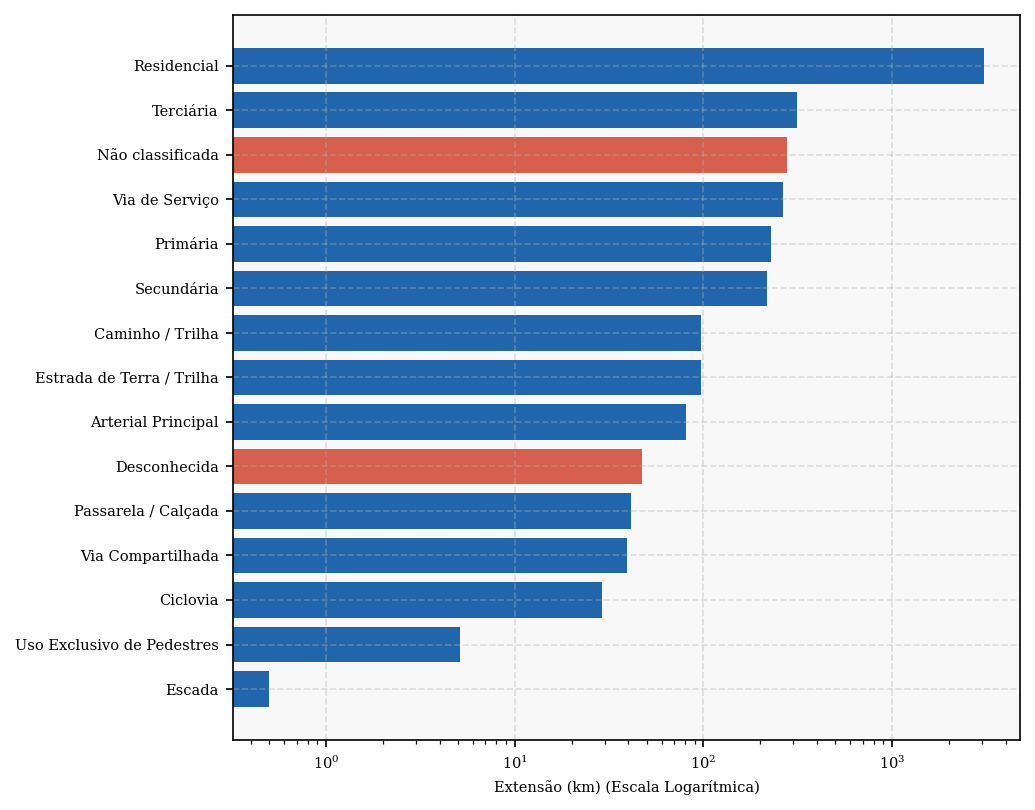

In [ ]:
# ── Fig. 07 — Extensão da rede por classe funcional ─────────────────────────
classes_ordenadas = tabela_classes.sort_values("extensao_km")

# 1. Dicionário abrangente de tradução das classes funcionais (Overture Maps/OSM)
traducao_classes = {
    "motorway": "Via Expressa",
    "trunk": "Arterial Principal",
    "primary": "Primária",
    "secondary": "Secundária",
    "tertiary": "Terciária",
    "residential": "Residencial",
    "living_street": "Via Compartilhada",
    "pedestrian": "Uso Exclusivo de Pedestres",
    "footway": "Passarela / Calçada",
    "path": "Caminho / Trilha",
    "track": "Estrada de Terra / Trilha",
    "service": "Via de Serviço",
    "cycleway": "Ciclovia",
    "steps": "Escada",
    "road": "Via Genérica (não especificada)",
    "unclassified": "Não classificada",
    "unknown": "Desconhecida"
}

# 2. Aplica a tradução aos rótulos do eixo Y
rotulos_traduzidos = [traducao_classes.get(str(classe).lower(), str(classe).title())
                      for classe in classes_ordenadas.index]

fig, ax = plt.subplots(figsize=(7, 5.5))

# A lógica de cores continua usando o índice original em inglês para não quebrar a sua constante
cores_classes = [
    "#D6604D" if classe in CLASSES_SEM_HIERARQUIA else "#2166AC"
    for classe in classes_ordenadas.index
]

# 3. Plota as barras substituindo o índice pelos rótulos traduzidos
ax.barh(rotulos_traduzidos, classes_ordenadas["extensao_km"], color=cores_classes)

ax.set_xscale("log")
ax.set_xlabel("Extensão (km) (Escala Logarítmica)", fontsize=7)
# ax.set_title("Extensão da rede por classe funcional\n"
#              "(vermelho = sem hierarquia, alvo da imputação GNN)", fontsize=11)

# tick_params controla os DOIS eixos de uma vez, incluindo os nomes das
# classes (rotulos_traduzidos) que aparecem como "tick label" do eixo Y
ax.tick_params(axis="both", labelsize=7)

plt.tight_layout()
plt.savefig(FIGURAS_NB / "nb021_fig07_classes_funcionais.png", bbox_inches="tight")
plt.show()

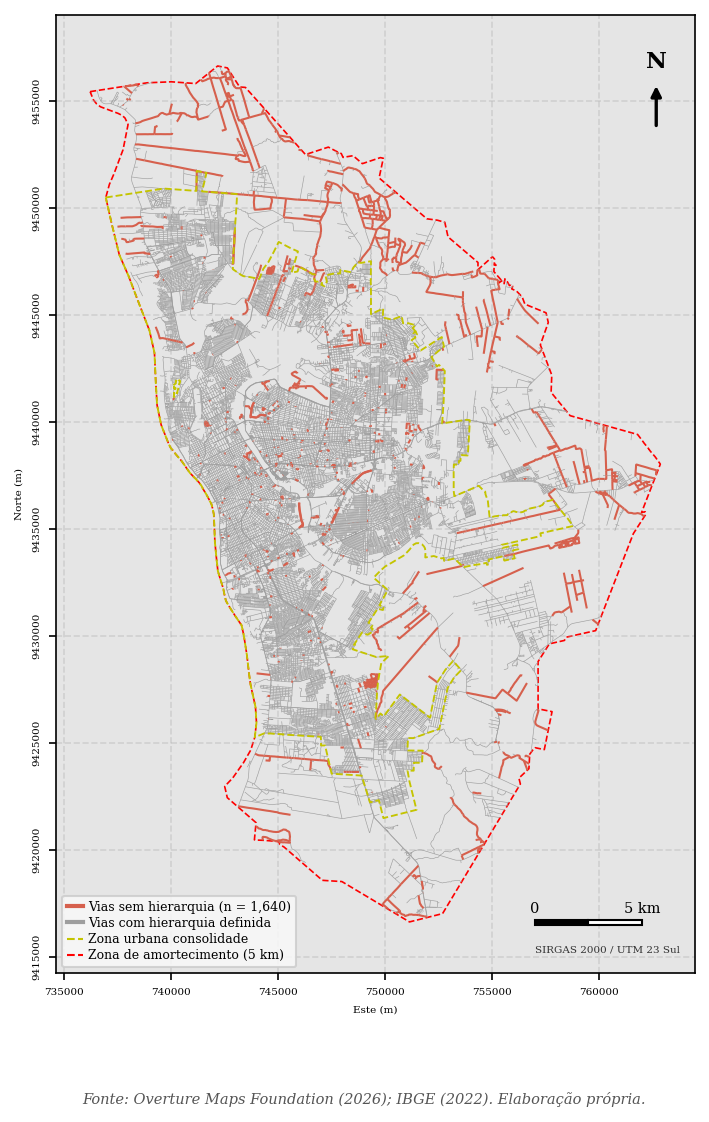

In [44]:
# ── Fig. 08 — Onde estão as vias sem classificação? ─────────────────────────
# Tamanhos de fonte de todos os elementos com texto — mexe só aqui pra ajustar
FONTE_LEGENDA = 6
FONTE_EIXOS   = 5
FONTE_CRS     = 5

fig, ax = plt.subplots(figsize=(5.8, 8.3)); ax.set_facecolor("#E5E5E5")

area_estudo_gdf.boundary.plot(ax=ax, color="#FF0000", ls="--", lw=0.8, zorder=1)
arestas_gdf[~arestas_gdf["sem_classe"]].plot(ax=ax, color="#9E9E9E", linewidth=0.3, zorder=2)
arestas_gdf[arestas_gdf["sem_classe"]].plot(ax=ax, color="#D6604D", linewidth=1.0, zorder=3)
zona_urbana_gdf.boundary.plot(ax=ax, color="#C4C400", ls="--", lw=0.9, zorder=4)

ax.legend(handles=[
    Line2D([], [], color="#D6604D", lw=2, label=f"Vias sem hierarquia (n = {n_sem_classe:,})"),
    Line2D([], [], color="#9E9E9E", lw=2, label="Vias com hierarquia definida"),
    Line2D([], [], color="#C4C400", ls="--", lw=1, label="Zona urbana consolidade"),
    Line2D([], [], color="#FF0000", ls="--", lw=1, label="Zona de amortecimento (5 km)"),
], loc="lower left", fontsize=FONTE_LEGENDA)

ajustar_zoom_camada(ax, area_estudo_gdf, margem=0.06)
moldura_mapa(ax, "", FONTE_PADRAO)
formatar_eixos_mapa(ax, fontsize=FONTE_EIXOS)

barra_escala(ax, frac_x=0.75, frac_y=0.05)
seta_norte(ax)

x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
ax.text(x0 + (x1 - x0) * 0.75, y0 + (y1 - y0) * 0.02,
        "SIRGAS 2000 / UTM 23 Sul", ha="left", va="bottom",
        fontsize=FONTE_CRS, color="#333333", zorder=10)

fig.savefig(FIGURAS_NB / "nb021_fig08_mapa_vias_sem_classe.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Síntese estatística da malha viária

Consolidação dos indicadores citados no capítulo de Metodologia. O CSV gerado alimenta
diretamente a tabela da dissertação — sem transcrição manual, sem risco de divergência
entre o texto e o dado.

In [45]:
# ── 7. SÍNTESE ESTATÍSTICA DA MALHA VIÁRIA ──────────────────────────────────
superficie_conhecida = arestas_gdf["surf_group"] != "Desconhecida"
pct_pavimentada_conhecida = (
    (arestas_gdf.loc[superficie_conhecida, "surf_group"] == "Pavimentada").mean() * 100
)

# Densidade viária: extensão de via DENTRO da Zona Urbana / área da Zona Urbana
area_zu_km2     = zona_urbana_gdf.area.sum() / 1e6
extensao_zu_km  = gpd.clip(arestas_gdf, zona_urbana_gdf).length.sum() / 1_000
densidade_viaria = extensao_zu_km / area_zu_km2

sintese = pd.DataFrame([
    ("Segmentos brutos (Overture)",                        f"{total_bruto:,}"),
    ("Segmentos rodoviários (pós-filtro semântico)",       f"{len(road_gdf):,}"),
    ("Arestas após correção topológica",                   f"{len(arestas_gdf):,}"),
    ("Nós do grafo",                                       f"{G.number_of_nodes():,}"),
    ("Componentes conexos",                                f"{n_componentes}"),
    ("Nós no componente gigante (%)",                      f"{pct_gigante:.2f}"),
    ("Pontas soltas / cul-de-sac (%)",                     f"{pct_pontas_soltas:.1f}"),
    ("Extensão total da rede (km)",                        f"{arestas_gdf['length_m'].sum() / 1_000:,.1f}"),
    ("Densidade viária na Zona Urbana (km/km²)",           f"{densidade_viaria:.2f}"),
    ("Comprimento mediano da aresta (m)",                  f"{arestas_gdf['length_m'].median():.1f}"),
    ("Linearidade média",                                  f"{arestas_gdf['linearity'].mean():.3f}"),
    ("Arestas com nome de via (%)",                        f"{arestas_gdf['nomes_vias'].notna().mean() * 100:.1f}"),
    ("Arestas com superfície conhecida (%)",               f"{superficie_conhecida.mean() * 100:.1f}"),
    ("— pavimentadas, entre as de superfície conhecida (%)", f"{pct_pavimentada_conhecida:.1f}"),
    ("Arestas com velocidade regulamentar (%)",            f"{arestas_gdf['velocidade_max'].notna().mean() * 100:.1f}"),
    ("Arestas sem hierarquia funcional (%)",               f"{arestas_gdf['sem_classe'].mean() * 100:.1f}"),
], columns=["indicador", "valor"])

sintese.to_csv(TABELAS_NB / "nb021_sintese_malha_viaria.csv", sep=";", index=False, encoding="utf-8-sig")  # BOM p/ Excel
sintese

,indicador,valor
0,Segmentos brutos (Overture),"46,970"
1,Segmentos rodoviários (pós-filtro semântico),"46,932"
2,Arestas após correção topológica,"52,977"
3,Nós do grafo,"35,187"
4,Componentes conexos,45
5,Nós no componente gigante (%),99.37
6,Pontas soltas / cul-de-sac (%),11.4
7,Extensão total da rede (km),"4,817.7"
8,Densidade viária na Zona Urbana (km/km²),15.29
9,Comprimento mediano da aresta (m),67.0


## 8. Exportação do grafo limpo

O arquivo gravado aqui é a **única fonte da verdade** que alimenta o NB 02.2. Formato
**GeoParquet**: preserva tipos de dados, ocupa uma fração do GeoJSON equivalente e
carrega ordens de magnitude mais rápido.

Mantemos apenas as colunas consumidas adiante — as estruturas aninhadas originais
(`names`, `road_surface`, `speed_limits`, ...) já foram traduzidas em colunas escalares
e ficariam como peso morto no arquivo.

In [30]:
# ── 8. EXPORTAÇÃO DO GRAFO LIMPO ────────────────────────────────────────────
COLUNAS_EXPORTACAO = [
    "aresta_id",        # chave primária única da aresta (criada na Seção 5.1)
    "id",               # identificador Overture — rastreabilidade até a fonte
                        #   (NÃO é único após o fatiamento; não usar como chave)
    "nomes_vias",       # nome legível — relatórios e auditoria visual
    "class",            # classe funcional — será completada pela GNN (NB 02.2)
    "classe_original",  # cópia de auditoria da classe bruta
    "sem_classe",       # marcador booleano dos alvos da imputação
    "surface_clean",    # superfície escalar — feature da GNN; impedância (NB 03)
    "surf_group",       # superfície em 3 grupos — cartografia e relatórios
    "velocidade_max",   # velocidade regulamentar empírica (km/h), quando houver
    "length_m",         # comprimento métrico — feature da GNN; impedância (NB 03)
    "linearity",        # tortuosidade [0–1] — feature da GNN
    "split_from",       # fração (0–1) do segmento original onde a aresta inicia
    "split_to",         # fração (0–1) onde termina — rastreiam o fatiamento (Seção 5)
    "geometry",
]
grafo_limpo = arestas_gdf[COLUNAS_EXPORTACAO].copy()

caminho_saida = INT_GRAFO / "zonaUrbana_5km_road_cleaned.parquet"
grafo_limpo.to_parquet(caminho_saida)

tamanho_mb = caminho_saida.stat().st_size / 1_048_576
print(f"💾 Grafo limpo salvo: {caminho_saida}")
print(f"   {len(grafo_limpo):,} arestas × {len(grafo_limpo.columns)} colunas "
      f"| {tamanho_mb:.1f} MB")

💾 Grafo limpo salvo: C:\Users\felipe\workspace_pcksa\ae2sfca_ubs\dados\intermediarios\02_grafo\zonaUrbana_5km_road_cleaned.parquet
   52,977 arestas × 14 colunas | 4.9 MB


---
## Próximos passos

O grafo está topologicamente íntegro e conexo (99,3% dos nós no componente gigante),
mas **incompleto em atributos**: parte das arestas não tem hierarquia funcional e,
portanto, não pode receber velocidade.

- **NB 02.2 — Imputação GNN**: usa as *features* preparadas aqui (`length_m`,
  `linearity`, superfície) e o contexto topológico (a vizinhança de cada aresta no
  grafo) para prever a classe funcional das arestas marcadas em `sem_classe`,
  identificadas pela chave `aresta_id`.
- **NB 03 — Impedâncias**: com a rede 100% classificada, atribui velocidades por
  classe (calibradas pela Seção 6.3) e converte cada aresta em **minutos de viagem**.